<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Neural_Networks/MiniProject_4_Urban_Traffic_Flow_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Urban Traffic Flow Prediction using Graph Convolution Network - LSTM

## Learning Objectives

At the end of the Mini Project, you will be able to :

* forecast traffic flow using Graph Convolutional Network and LSTM
* understand the graph structured data and implement the forecasting model

## Information

Accurate and real-time traffic forecasting plays an important role in the Intelligent Traffic System and is important for

- urban traffic planning,
- traffic management, and
- traffic control.

Traffic forecasting is a challenging issue because of the constraints of the urban road network topological structure and the law of dynamic change with time (spatial dependence and temporal dependence). To capture the spatial and temporal dependence simultaneously, a neural network-based traffic forecasting method called the temporal graph convolutional network (T-GCN) model is very useful. It is a combination of the graph convolutional network (GCN) and gated recurrent unit (GRU).

- Specifically, the GCN is used to learn complex topological structures to capture spatial dependence and the gated recurrent unit is used to learn dynamic changes of traffic data to capture temporal dependence. Then, the T-GCN model is employed to traffic forecasting based on the urban road network. T-GCN model can obtain the spatio-temporal correlation from traffic data and the predictions outperform state-of-art baselines on real-world traffic datasets.

Reference: https://arxiv.org/abs/1811.05320

## Dataset



Urban Traffic Prediction from Spatio-Temporal Data Using Deep Meta Learning.

This traffic dataset contains traffic information collected from loop detectors in the highway of Los Angeles County (Jagadish et al., 2014). This dataset contains traffic speeds from Mar-1 to Mar-7, 2012 of 207 sensors, recorded every 5 minutes.  There are 2016 observations (timesteps) of speed records over 207 sensors. Speeds are recorded every 5 minutes. This means that, for a single hour, you will have 12 observations. Similarly, a single day will contain 288 (12x24) observations. Overall, the data consists of speeds recorded every 5 minutes over 207 for 7 days (12X24X7).

Data Source:
https://github.com/lehaifeng/T-GCN/tree/master/data

## Problem Statement

#### Forecasting urban traffic flow using spatio-temporal data with combined Graph Convolution + LSTM model

## Grading = 10 Points

In [ ]:
#@title Download dataset
!wget -qq https://raw.githubusercontent.com/lehaifeng/T-GCN/master/data/los_adj.csv
!wget -qq https://raw.githubusercontent.com/lehaifeng/T-GCN/master/data/los_speed.csv
!pip -qq install chardet
!pip -qq install git+https://github.com/VenkateshwaranB/stellargraph.git

  Preparing metadata (setup.py) ... done


### Import required packages

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential, Model
from keras.layers import LSTM, Dense, Dropout, Input, RepeatVector, TimeDistributed
import stellargraph as sg
from stellargraph.layer import GCN
from stellargraph.layer import GCN_LSTM
import networkx as nx

### Data loading and preparation ( 2 points)

In [ ]:
adj_path = "/content/los_adj.csv"
speed_data_path= "/content/los_speed.csv"

In [ ]:
# YOUR CODE HERE

In [ ]:
dfAdj = pd.read_csv(adj_path, header=None)
dfSpeed = pd.read_csv(speed_data_path, header=None)

In [ ]:
dfAdj.head()

,0,1,2,3,4,5,6,7,8,9,...,197,198,199,200,201,202,203,204,205,206
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.119804,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.000000,0.717438,0.000000,0.000000,0.000000,0.000000,0.390457,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.717438,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.000000,1.000000,0.633722,0.894812,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.000000,0.633722,1.000000,0.361432,0.135197,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
dfSpeed.head()

,0,1,2,3,4,5,6,7,8,9,...,197,198,199,200,201,202,203,204,205,206
0,773869.000000,767541.000000,767542.000000,717447.000000,717446.000000,717445.000000,773062.000000,767620.000000,737529.000000,717816.000000,...,772167.000000,769372.000000,774204.000000,769806.000000,717590.000000,717592.000000,717595.000000,772168.000000,718141.000000,769373.000000
1,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
3,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
4,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444


In [ ]:
dfSpeed.shape

(2017, 207)

In [ ]:
dfSpeed.columns = dfSpeed.iloc[0]
dfSpeed = dfSpeed.drop(0)

In [ ]:
dfSpeed.shape


(2016, 207)

In [ ]:
dfSpeed.head()

,773869.0,767541.0,767542.0,717447.0,717446.0,717445.0,773062.0,767620.0,737529.0,717816.0,...,772167.0,769372.0,774204.0,769806.0,717590.0,717592.0,717595.0,772168.0,718141.0,769373.0
1,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
3,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
4,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444
5,59.555556,67.250000,65.111111,60.777778,67.055556,68.083333,61.944444,66.305556,63.291667,64.013889,...,42.708333,69.666667,64.388889,57.972222,66.708333,57.277778,64.986111,58.902778,69.285714,58.888889


In [ ]:
#Finding the null values
dfSpeed.isnull().sum()

0
773869.0    0
767541.0    0
767542.0    0
717447.0    0
717446.0    0
           ..
717592.0    0
717595.0    0
772168.0    0
718141.0    0
769373.0    0
Length: 207, dtype: int64

In [ ]:
dfAdj.isnull().sum()

0      0
1      0
2      0
3      0
4      0
      ..
202    0
203    0
204    0
205    0
206    0
Length: 207, dtype: int64

In [ ]:
dfSpeed.head()

,773869.0,767541.0,767542.0,717447.0,717446.0,717445.0,773062.0,767620.0,737529.0,717816.0,...,772167.0,769372.0,774204.0,769806.0,717590.0,717592.0,717595.0,772168.0,718141.0,769373.0
1,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
3,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
4,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444
5,59.555556,67.250000,65.111111,60.777778,67.055556,68.083333,61.944444,66.305556,63.291667,64.013889,...,42.708333,69.666667,64.388889,57.972222,66.708333,57.277778,64.986111,58.902778,69.285714,58.888889


In [ ]:
npSpeed = dfSpeed.to_numpy()

In [ ]:
dfAdj.head()


,0,1,2,3,4,5,6,7,8,9,...,197,198,199,200,201,202,203,204,205,206
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.119804,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.000000,0.717438,0.000000,0.000000,0.000000,0.000000,0.390457,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.717438,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.000000,1.000000,0.633722,0.894812,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.000000,0.633722,1.000000,0.361432,0.135197,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
npAdj = dfAdj.to_numpy()

In [ ]:
npAdj

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.71743792, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.71743792, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.        ]])

#### Plotting the time series of 10 sensors data

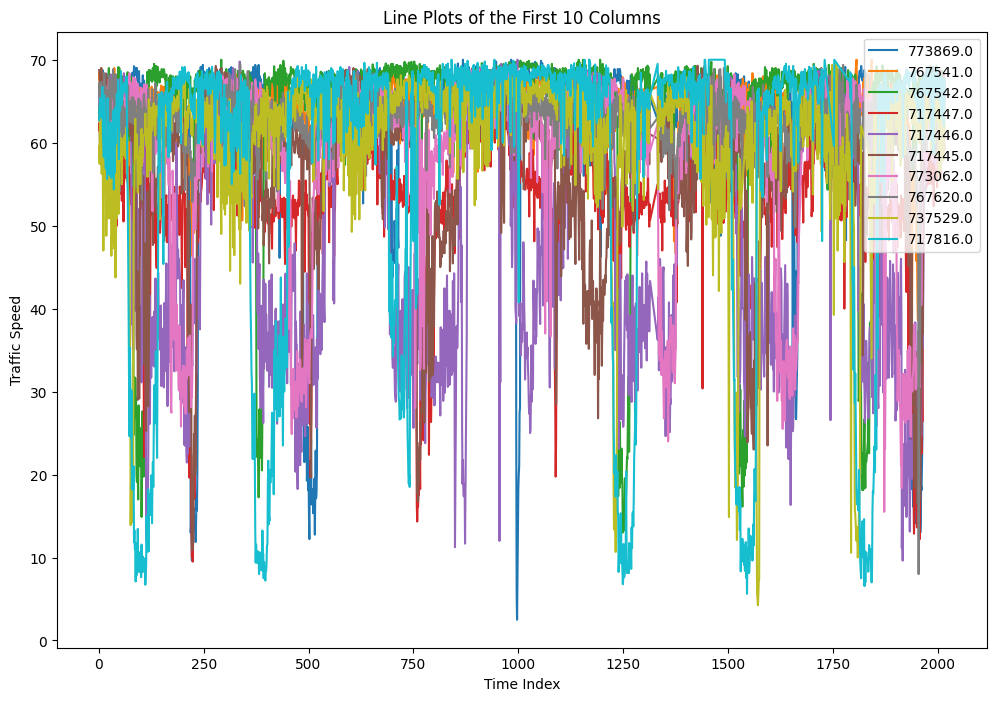

In [ ]:
# YOUR CODE HERE
dfSpeed_first_10 = dfSpeed.iloc[:, :10]

# Plotting
plt.figure(figsize=(12, 8))
for column in dfSpeed_first_10.columns:
    plt.plot(dfSpeed_first_10.index, dfSpeed_first_10[column], label=column)

plt.xlabel('Time Index')
plt.ylabel('Traffic Speed')
plt.title('Line Plots of the First 10 Columns')
plt.legend(loc='upper right')
plt.show()

#### Create and draw the graph of adjacency of matrix

Hint: [link](https://towardsdatascience.com/graph-coloring-with-networkx-88c45f09b8f4)

In [ ]:
def visualizeAdjMatrix(G):
    pos = nx.spring_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size=100)
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos)
    plt.axis('off')
    plt.show()

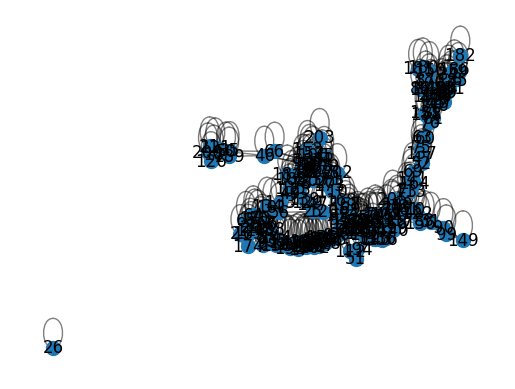

In [ ]:
# YOUR CODE HERE
npAdjBinary = np.where(npAdj > 0, 1, npAdj)
npAdjBinary
G = nx.from_numpy_array(npAdjBinary)
visualizeAdjMatrix(G)

In [ ]:
npAdjBinary

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
len(npAdjBinary)

207

In [ ]:
for i in range(len(npAdjBinary)):
    npAdjBinary[i][i] = 0

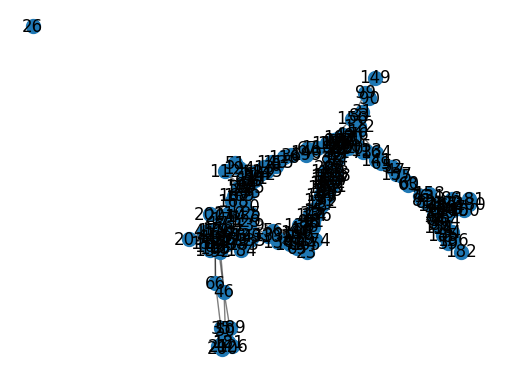

In [ ]:
G = nx.from_numpy_array(npAdjBinary)
visualizeAdjMatrix(G)

In [ ]:
# Get the indices of non-zero elements
adjRows, adjCols = np.where(npAdjBinary != 0)

# Use zip to pair row and column indices
edges = list(zip(adjRows, adjCols))

# Print the list of edges
print(edges)

[(0, 0), (0, 13), (0, 36), (0, 37), (0, 42), (0, 54), (0, 58), (0, 67), (0, 111), (0, 114), (0, 115), (0, 116), (0, 118), (0, 125), (0, 140), (0, 142), (0, 143), (0, 145), (0, 199), (1, 1), (1, 2), (1, 7), (1, 27), (1, 28), (1, 78), (1, 79), (1, 101), (1, 107), (1, 123), (1, 133), (1, 135), (1, 139), (1, 177), (1, 183), (1, 184), (2, 1), (2, 2), (2, 27), (2, 28), (2, 49), (2, 78), (2, 79), (2, 85), (2, 108), (2, 123), (2, 129), (2, 132), (2, 135), (2, 177), (2, 183), (3, 3), (3, 4), (3, 5), (3, 12), (3, 15), (3, 17), (3, 33), (3, 38), (3, 80), (3, 91), (3, 136), (3, 144), (3, 161), (3, 188), (3, 191), (3, 192), (3, 193), (3, 195), (4, 3), (4, 4), (4, 5), (4, 6), (4, 12), (4, 15), (4, 16), (4, 17), (4, 33), (4, 80), (4, 91), (4, 93), (4, 136), (4, 138), (4, 144), (4, 160), (4, 187), (4, 191), (4, 192), (4, 193), (4, 195), (5, 3), (5, 4), (5, 5), (5, 15), (5, 16), (5, 17), (5, 33), (5, 38), (5, 48), (5, 80), (5, 91), (5, 93), (5, 136), (5, 144), (5, 188), (5, 191), (5, 192), (5, 195), (6

In [ ]:
len(edges)

2833

In [ ]:
trafficNetwork = nx.Graph()
trafficNetwork.add_nodes_from(dfSpeed.columns)
trafficNetwork.add_edges_from(edges)

In [ ]:
dfSpeed.columns

Index([773869.0, 767541.0, 767542.0, 717447.0, 717446.0, 717445.0, 773062.0,
       767620.0, 737529.0, 717816.0,
       ...
       772167.0, 769372.0, 774204.0, 769806.0, 717590.0, 717592.0, 717595.0,
       772168.0, 718141.0, 769373.0],
      dtype='float64', name=0, length=207)

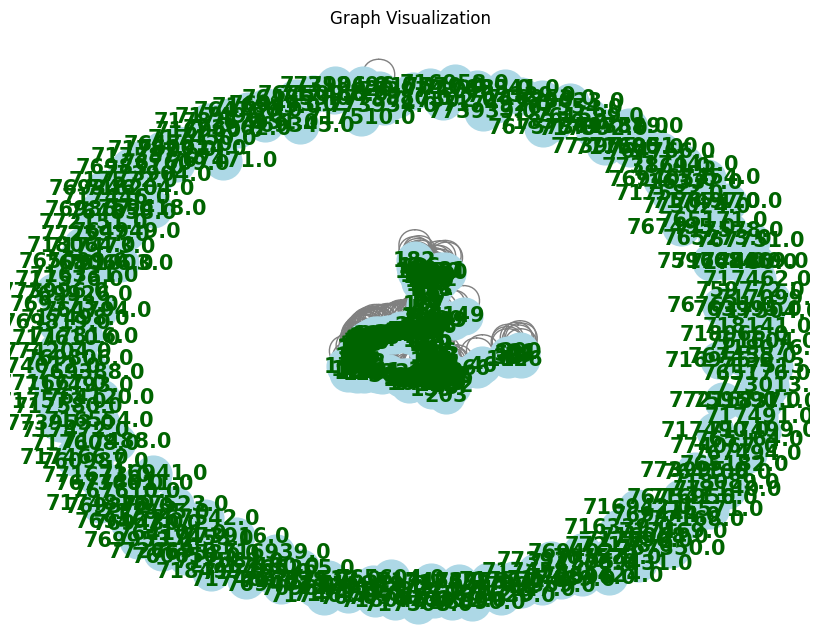

In [ ]:
# Draw the graph
plt.figure(figsize=(8, 6))
nx.draw(trafficNetwork, with_labels=True, node_color='lightblue', node_size=700, font_size=15, font_color='darkgreen', edge_color='gray', linewidths=1, font_weight='bold')
plt.title("Graph Visualization")
plt.show()

#### Preprocessing and train test split

In [ ]:
dfSpeed.head()

,773869.0,767541.0,767542.0,717447.0,717446.0,717445.0,773062.0,767620.0,737529.0,717816.0,...,772167.0,769372.0,774204.0,769806.0,717590.0,717592.0,717595.0,772168.0,718141.0,769373.0
1,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
3,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
4,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444
5,59.555556,67.250000,65.111111,60.777778,67.055556,68.083333,61.944444,66.305556,63.291667,64.013889,...,42.708333,69.666667,64.388889,57.972222,66.708333,57.277778,64.986111,58.902778,69.285714,58.888889


In [ ]:
trafficNetwork.nodes()

NodeView((773869.0, 767541.0, 767542.0, 717447.0, 717446.0, 717445.0, 773062.0, 767620.0, 737529.0, 717816.0, 765604.0, 767471.0, 716339.0, 773906.0, 765273.0, 716331.0, 771667.0, 716337.0, 769953.0, 769402.0, 769403.0, 769819.0, 769405.0, 716941.0, 717578.0, 716960.0, 717804.0, 767572.0, 767573.0, 773012.0, 773013.0, 764424.0, 769388.0, 716328.0, 717819.0, 769941.0, 760987.0, 718204.0, 718045.0, 769418.0, 768066.0, 772140.0, 773927.0, 760024.0, 774012.0, 774011.0, 767609.0, 769359.0, 760650.0, 716956.0, 769831.0, 761604.0, 717495.0, 716554.0, 773953.0, 767470.0, 716955.0, 764949.0, 773954.0, 767366.0, 769444.0, 773939.0, 774067.0, 769443.0, 767750.0, 767751.0, 767610.0, 773880.0, 764766.0, 717497.0, 717490.0, 717491.0, 717492.0, 717493.0, 765176.0, 717498.0, 717499.0, 765171.0, 718064.0, 718066.0, 765164.0, 769431.0, 769430.0, 717610.0, 767053.0, 767621.0, 772596.0, 772597.0, 767350.0, 767351.0, 716571.0, 773023.0, 767585.0, 773024.0, 717483.0, 718379.0, 717481.0, 717480.0, 717486.0, 

[767542.0]


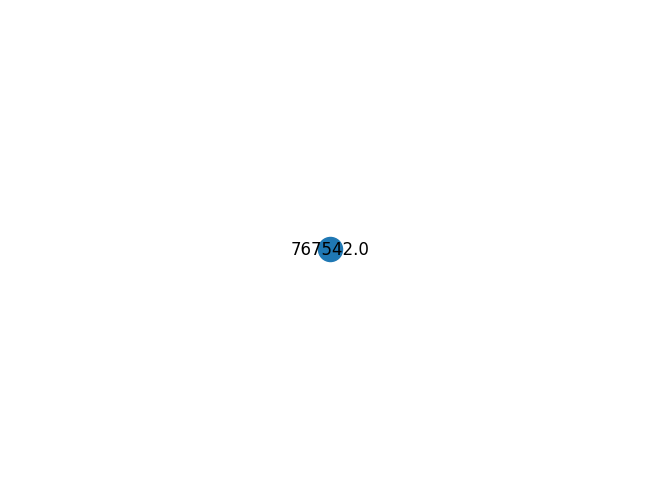

In [ ]:
ego = 767542.0
ego_graph = nx.ego_graph(trafficNetwork, ego, radius=2, undirected=True)
print(ego_graph.nodes())
nx.draw(ego_graph, with_labels=True)

In [ ]:
npSpeedTrans = npSpeed.T

In [ ]:
npSpeedTrans.shape


(207, 2016)

In [ ]:
seq_len = 10
pre_len = 12

input_length = seq_len
output_index = seq_len + pre_len - 1

# Initialize lists to store inputs and outputs
inputs = []
outputs = []

# Iterate over each row
for row in npSpeedTrans:
    # Slide the window across the row

    for start in range(len(row) - input_length - pre_len + 1):
        # Define the end of the input window
        end = start + input_length
        # Append the input and output to the lists
        inputs.append(row[start:end])
        outputs.append(row[end + pre_len - 1])

# Convert lists to NumPy arrays
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Inputs shape:", inputs.shape)
print("Outputs shape:", outputs.shape)


Inputs shape: (412965, 10)
Outputs shape: (412965,)


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((330372, 10), (82593, 10), (330372,), (82593,))

In [ ]:
# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler on the training data
scaler.fit(X_train)

# Transform the training data
X_train_scaled = scaler.transform(X_train)

# Transform the test data
X_test_scaled = scaler.transform(X_test)

#### Prepare Time series data


Aim is to use 50 minutes of historical speed observations to predict the speed in future (1 hour ahead)

* Choose windows of 10 historical observations i.e. 5 * 10 = 50 minutes (`seq_len`) for each segment as the input and use it to predict the speed after 5 * 12 = 60 minutes (target) using the sliding window approach.

**Note:**
The below parameters
-  `seq_len` is the size of the past window of information.
- `pre_len` is future prediction ( 1 hour in future = 12 * 5 minutes)



Steps:

* Prepare the data to be fed into an LSTM. The LSTM model learns a function that maps a **sequence of past observations as input to an output observation**, so the sequence of observations must be transformed into multiple examples from which the LSTM can learn.

* Choose to use 50 minutes of historical speed observations to predict the speed in future (eg. 1 hour ahead). First reshape the timeseries data into windows of 10 historical observations for each segment as the input and the speed 60 minutes later as the prediction label. This can be performed using a sliding window approach:

    - Starting from the beginning of the timeseries, we take the first 10 speed records as the 10 input features and the speed 12 timesteps head (60 minutes) as the speed we want to predict.

    - Shift the timeseries by one timestep and take the 10 observations from the current point as the input features and the speed one hour ahead as the output to predict.

    - Keep shifting by 1 timestep and picking the 10 timestep window from the current time as input feature and the speed one hour ahead of the 10th timestep as the output to predict, for the entire data.

  *Note: The above steps are done for each sensor.*

Define a function below to return the above transformed timeseries data for the model to train on. The parameter seq_len is the size of the past window of information. The pre_len is how far in the future does the model need to learn to predict.

Each **training observation** is 10 historical speeds **(seq_len).**

Each **training prediction** is the speed 60 minutes later **(pre_len).**

In [ ]:
seq_len = 10
pre_len = 12
# YOUR CODE HERE

### Build and Train the LSTM model and plot the loss results (3 points)

In [ ]:
# YOUR CODE HERE
inputsLSTM = keras.Input(shape=(seq_len,1))
x = keras.layers.LSTM(16)(inputsLSTM)
outputsLSTM = keras.layers.Dense(1)(x)
modelLSTM = keras.Model(inputsLSTM, outputsLSTM)

callbacks = [
keras.callbacks.ModelCheckpoint("jena_lstm.keras",
save_best_only=True)
]
modelLSTM.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


In [ ]:
history = modelLSTM.fit(X_train_scaled, y_train,
epochs=10,
batch_size=16,
callbacks=callbacks)

Epoch 1/10
20645/20649 [============================>.] - ETA: 0s - loss: 251.3141 - mae: 9.2817

20649/20649 [==============================] - 138s 7ms/step - loss: 251.2873 - mae: 9.2810
Epoch 2/10
20643/20649 [============================>.] - ETA: 0s - loss: 77.4041 - mae: 5.0305

20649/20649 [==============================] - 131s 6ms/step - loss: 77.4021 - mae: 5.0305
Epoch 3/10
20644/20649 [============================>.] - ETA: 0s - loss: 76.7784 - mae: 4.9860

20649/20649 [==============================] - 131s 6ms/step - loss: 76.7828 - mae: 4.9862
Epoch 4/10
11476/20649 [===============>..............] - ETA: 58s - loss: 76.0722 - mae: 4.9338

In [ ]:
# Evaluate the model on the validation data
loss, accuracy = modelLSTM.evaluate(X_test_scaled, y_test)

print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

2582/2582 [==============================] - 8s 3ms/step - loss: 75.7265 - mae: 4.7530
Test Loss: 75.72653198242188
Test Accuracy: 4.7530107498168945


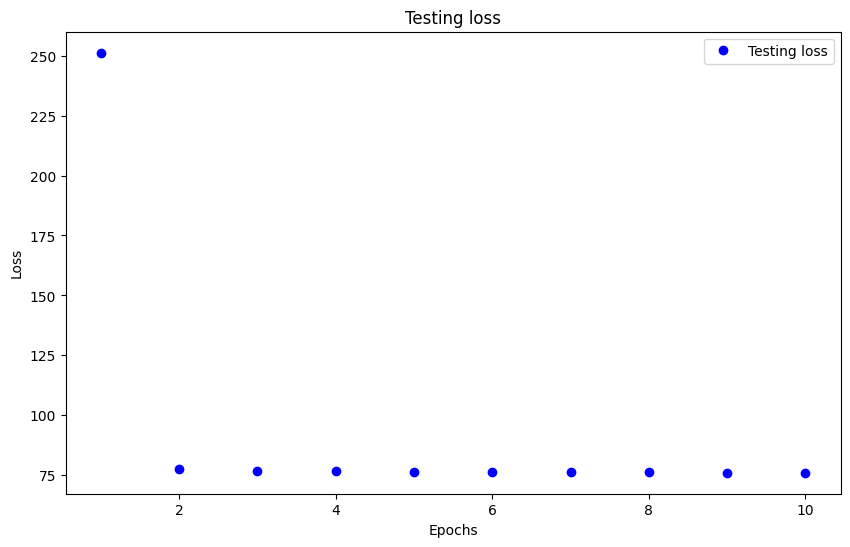

In [ ]:
# YOUR CODE HERE to plot the loss
# Extract loss values from the history object
loss = history.history['loss']
#val_loss = history.history['val_loss']

# Create a plot
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo', label='Testing loss')
#plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Testing loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

### StellarGraph Graph Convolution and LSTM model ( 3 points)

In order to use the model, we need:

* An **N by N** adjacency matrix, which describes the distance relationship between the N sensors,

* An **N by T** feature matrix, which describes the ($f_1, .., f_T$) speed records over T timesteps for the N sensors.

Arguments of GCN_LSTM:
  - seq_len: No. of LSTM cells

  - adj: unweighted/weighted adjacency matrix

  - gc_layer_sizes (list of int): Output sizes of Graph Convolution  layers in the stack.

  - lstm_layer_sizes (list of int): Output sizes of LSTM layers in the stack.

  - gc_activations (list of str or func): Activations applied to each layer's output.

  - lstm_activations (list of str or func): Activations applied to each layer's output; defaults to ``['tanh', ..., 'tanh']``.

In [ ]:
npAdjBinary.shape

(207, 207)

In [ ]:
npSpeedTrans.shape

(207, 2016)

In [ ]:
dfSpeedTrans = dfSpeed.T

N x N Adjacency Matrix:  npAdjBinary

N x T Feature Matrix: npSpeedTrans

In [ ]:
def train_test_split(data, train_portion):
    time_len = data.shape[1]
    train_size = int(time_len * train_portion)
    train_data = np.array(data.iloc[:, :train_size])
    test_data = np.array(data.iloc[:, train_size:])
    return train_data, test_data

In [ ]:
train_rate = 0.8

In [ ]:
train_data, test_data = train_test_split(dfSpeedTrans, train_rate)
print("Train data: ", train_data.shape)
print("Test data: ", test_data.shape)

Train data:  (207, 1612)
Test data:  (207, 404)


In [ ]:
def scale_data(train_data, test_data):
    max_speed = train_data.max()
    min_speed = train_data.min()
    train_scaled = (train_data - min_speed) / (max_speed - min_speed)
    test_scaled = (test_data - min_speed) / (max_speed - min_speed)
    return train_scaled, test_scaled

In [ ]:
train_scaled, test_scaled = scale_data(train_data, test_data)

In [ ]:
seq_len = 10
pre_len = 12

In [ ]:
def sequence_data_preparation(seq_len, pre_len, train_data, test_data):
    trainX, trainY, testX, testY = [], [], [], []

    for i in range(train_data.shape[1] - int(seq_len + pre_len - 1)):
        a = train_data[:, i : i + seq_len + pre_len]
        trainX.append(a[:, :seq_len])
        trainY.append(a[:, -1])

    for i in range(test_data.shape[1] - int(seq_len + pre_len - 1)):
        b = test_data[:, i : i + seq_len + pre_len]
        testX.append(b[:, :seq_len])
        testY.append(b[:, -1])

    trainX = np.array(trainX)
    trainY = np.array(trainY)
    testX = np.array(testX)
    testY = np.array(testY)

    return trainX, trainY, testX, testY

In [ ]:
trainX, trainY, testX, testY = sequence_data_preparation(
    seq_len, pre_len, train_scaled, test_scaled
)
print(trainX.shape)
print(trainY.shape)
print(testX.shape)
print(testY.shape)

(1591, 207, 10)
(1591, 207)
(383, 207, 10)
(383, 207)


In [ ]:
gcn_lstm = GCN_LSTM(
    seq_len=seq_len,
    adj=npAdjBinary,
   # gc_layer_sizes=[16, 10],# Commented by Priyanka
    gc_layer_sizes=[36, 20],
    gc_activations=["relu", "relu"],
   # lstm_layer_sizes=[200, 200],# Commented by Priyanka
    lstm_layer_sizes=[400, 400],
    lstm_activations=["tanh", "tanh"],
)

<ipython-input-75-cbff4be7c414>:1: ExperimentalWarning: GCN_LSTM is experimental: Lack of unit tests and code refinement (see: https://github.com/stellargraph/stellargraph/issues/1132, https://github.com/stellargraph/stellargraph/issues/1526, https://github.com/stellargraph/stellargraph/issues/1564). It may be difficult to use and may have major changes at any time.
  gcn_lstm = GCN_LSTM(


In [ ]:
x_input, x_output = gcn_lstm.in_out_tensors()
model = Model(inputs=x_input, outputs=x_output)
model.compile(optimizer="adam", loss="mae", metrics=["mse"])

In [ ]:
history = model.fit(
    trainX,
    trainY,
    epochs=100,
    batch_size=60,
    shuffle=True,
    # verbose=0,
    validation_data=[testX, testY],
)

Epoch 1/100
27/27 [==============================] - 22s 638ms/step - loss: 0.1506 - mse: 0.0504 - val_loss: 0.1178 - val_mse: 0.0457
Epoch 2/100
27/27 [==============================] - 19s 725ms/step - loss: 0.1012 - mse: 0.0313 - val_loss: 0.1088 - val_mse: 0.0428
Epoch 3/100
27/27 [==============================] - 17s 624ms/step - loss: 0.0933 - mse: 0.0288 - val_loss: 0.1055 - val_mse: 0.0407
Epoch 4/100
27/27 [==============================] - 16s 595ms/step - loss: 0.0901 - mse: 0.0281 - val_loss: 0.1053 - val_mse: 0.0408
Epoch 5/100
27/27 [==============================] - 16s 617ms/step - loss: 0.0883 - mse: 0.0278 - val_loss: 0.1065 - val_mse: 0.0415
Epoch 6/100
27/27 [==============================] - 16s 593ms/step - loss: 0.0870 - mse: 0.0273 - val_loss: 0.1026 - val_mse: 0.0379
Epoch 7/100
27/27 [==============================] - 16s 607ms/step - loss: 0.0858 - mse: 0.0267 - val_loss: 0.1036 - val_mse: 0.0391
Epoch 8/100
27/27 [==============================] - 16s 592ms

KeyboardInterrupt: 

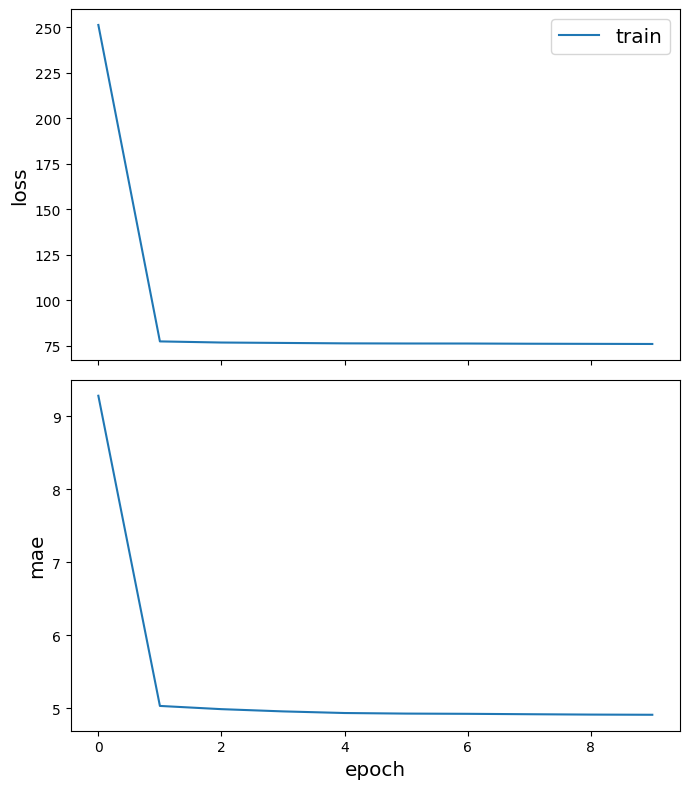

In [ ]:
sg.utils.plot_history(history)

#### Rescale values
Rescale the predicted values to the original value range of the timeseries.

In [ ]:
# YOUR CODE HERE
ythat = model.predict(trainX)
yhat = model.predict(testX)

## Rescale values
max_speed = train_data.max()
min_speed = train_data.min()

## actual train and test values
train_rescref = np.array(trainY * max_speed)
test_rescref = np.array(testY * max_speed)

## predicted train and test values
train_rescref_pred = np.array(ythat * max_speed)
test_rescref_pred = np.array(yhat * max_speed)



12/12 [==============================] - 1s 96ms/step


### Plot the predictions and Loss of each sensor ( 2 points)

* Select any one sensor's prediction and plot the graph.

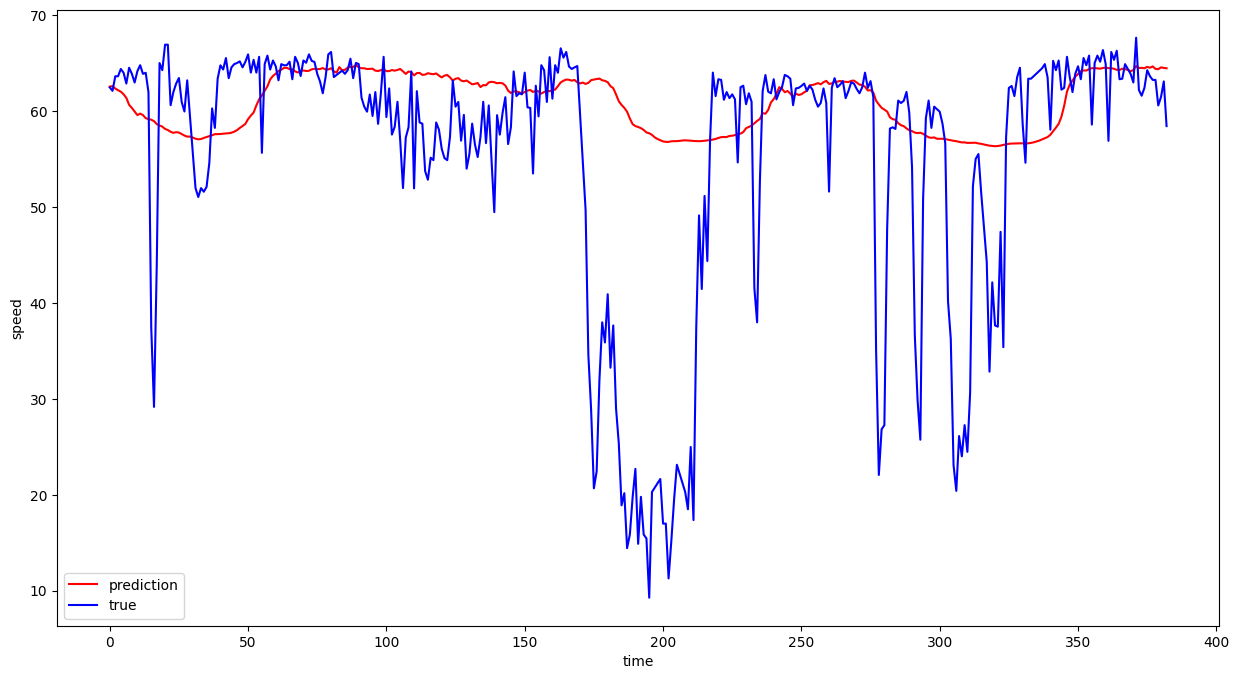

In [ ]:
# YOUR CODE HERE
##all test result visualization
fig1 = plt.figure(figsize=(15, 8))
#    ax1 = fig1.add_subplot(1,1,1)
a_pred = test_rescref_pred[:, 100]
a_true = test_rescref[:, 100]
plt.plot(a_pred, "r-", label="prediction")
plt.plot(a_true, "b-", label="true")
plt.xlabel("time")
plt.ylabel("speed")
plt.legend(loc="best", fontsize=10)
plt.show()


#### Plot error (MAE and MSE) for all the sensors

In [ ]:
# YOUR CODE HERE
test_rescref.shape


(383, 207)

#### Report Analysis

  * Discuss: Why is this called a spatio-temporal problem?

  * Discuss: In what way is GCN-LSTM more useful for the traffic prediction task than LSTM?

In [ ]:
# Implement GCN-LSTM
# YOUR CODE HERE

# from stellargraph import StellarGraph

# # Create a NetworkX graph
# G = nx.from_numpy_array(npAdjBinary)

# # Create node features if you have them
# node_features = {node: [1] for node in G.nodes()}

# # Convert NetworkX graph to StellarGraph
# stGraph = StellarGraph.from_networkx(G, node_features=node_features)


# from sklearn.model_selection import train_test_split

# nodes = list(graph.nodes())
# train_nodes, test_nodes = train_test_split(nodes, test_size=0.2, random_state=42)


# from stellargraph.layer import GCN
# from stellargraph.mapper import FullBatchNodeGenerator
# from tensorflow.keras import Model
# from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# # Create a generator
# generator = FullBatchNodeGenerator(stGraph, method="gcn")

# # Define GCN layer
# gcn = GCN(layer_sizes=[32, 32], activations=["relu", "relu"], generator=generator)

# # Create input and GCN layers
# x_inp, x_out = gcn.in_out_tensors()

# # Define LSTM layers
# x_lstm = LSTM(32)(x_out)
# x_lstm = Dropout(0.5)(x_lstm)
# predictions = Dense(units=1, activation="sigmoid")(x_lstm)

# # Create a Keras model
# model = Model(inputs=x_inp, outputs=predictions)
